# Regresion Basica: Predecir eficiencia de gasolina

Este libro usa el set de datos clasico [Auto MPG](https://archive.ics.uci.edu/ml/datasets/auto+mpg) y construye un modelo para predecir el consumo de vehiculos de 1970 y 1980. Para hacer esto proveeremos el modelo con una descripcion de muchos automoviles de ese periodo. Esta descripcion incluye atributos como: Cilindros, desplazamiento, potencia y peso.

El objetivo de este ejercicio es predecir el target miles per galon (MPG), que vendría a representar las millas por galón de combustible.

Este ejemplo usa el API `tf.keras` , revise [Esta Guia](https://www.tensorflow.org/guide/keras) para obtener mas detalles.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.16.2


## El set de Datos de MPG

El set de datos esta disponible de el siguiente repositorio [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/).

### Obtenga los datos
Primero descargue el set de datos.
keras.utils.get_file("auto-mpg.data", "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data")

In [2]:
dataset_path = keras.utils.get_file(
    "auto-mpg.data",
    "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"
)

In [3]:
column_names = ["MPG", "Cylinders", "Displacement", "Horsepower", "Weight", "Acceleration", "Model Year", "Origin", "Car name"]

Importelo usando pandas.

In [4]:
raw_dataset = pd.read_csv(
    dataset_path,
    names=column_names,
    na_values="?",
    comment="\t",
    sep=" ",
    skipinitialspace=True
)

dataset = raw_dataset.copy()
dataset.head()

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin,Car name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,NaN
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,NaN
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,NaN
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,NaN
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,NaN


### Limpia los datos

Trata los missings y variables categóricas

In [5]:
# Quitamos la columna de texto
dataset = dataset.drop(columns=["Car name"])

# Vemos cuántos NaN hay
print("NaNs por columna:")
print(dataset.isna().sum())

NaNs por columna:
MPG             0
Cylinders       0
Displacement    0
Horsepower      6
Weight          0
Acceleration    0
Model Year      0
Origin          0
dtype: int64


In [6]:
# Eliminamos las filas con NaN
dataset = dataset.dropna()

# One-hot encoding de Origin
dataset["Origin"] = dataset["Origin"].map({1: "USA", 2: "Europe", 3: "Japan"})
dataset = pd.get_dummies(dataset, columns=["Origin"], prefix="", prefix_sep="")
# Aseguramos tipo float (get_dummies devuelve bool en versiones recientes de pandas)
for c in ["USA", "Europe", "Japan"]:
    dataset[c] = dataset[c].astype(float)

dataset.tail()

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Europe,Japan,USA
393,27.0,4,140.0,86.0,2790.0,15.6,82,0.0,0.0,1.0
394,44.0,4,97.0,52.0,2130.0,24.6,82,1.0,0.0,0.0
395,32.0,4,135.0,84.0,2295.0,11.6,82,0.0,0.0,1.0
396,28.0,4,120.0,79.0,2625.0,18.6,82,0.0,0.0,1.0
397,31.0,4,119.0,82.0,2720.0,19.4,82,0.0,0.0,1.0


### Divide los datos en train y test

Ahora divida el set de datos en un set de entrenamiento y otro de pruebas. 80% para entrenamiento

Usaremos el set de pruebas en la evaluacion final de nuestro modelo.

NOTA: El resultado tienen que ser dos datasets

In [7]:
train_dataset = dataset.sample(frac=0.8, random_state=42)
test_dataset = dataset.drop(train_dataset.index)

print("Train:", train_dataset.shape)
print("Test :", test_dataset.shape)

Train: (314, 10)
Test : (78, 10)


### Inspecciona los datos

Revise rapidamente la distribucion conjunta del dataset de entrenamiento mediante un grid de gráficos

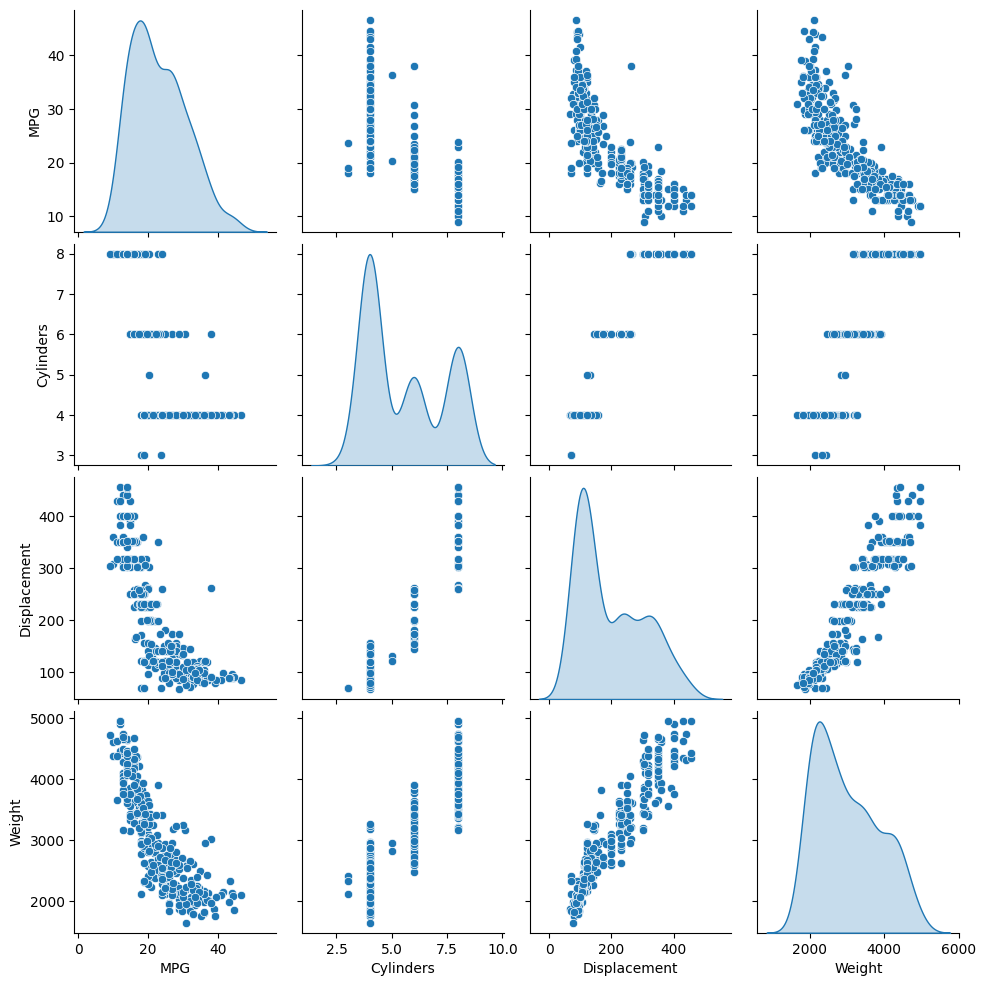

In [8]:
# Pairplot de las variables principales
sns.pairplot(
    train_dataset[["MPG", "Cylinders", "Displacement", "Weight"]],
    diag_kind="kde"
)
plt.show()

Tambien revise las estadisticas generales:

In [9]:
# Estadísticas descriptivas (transpuestas para verlas mejor)
train_stats = train_dataset.describe().transpose()
train_stats

,count,mean,std,min,25%,50%,75%,max
MPG,314.0,23.153822,7.861854,9.0,17.000,22.0,28.075,46.6
Cylinders,314.0,5.531847,1.729449,3.0,4.000,4.0,8.000,8.0
Displacement,314.0,197.855096,106.501896,68.0,105.000,151.0,302.000,455.0
Horsepower,314.0,105.971338,39.636557,46.0,76.000,95.0,130.000,230.0
Weight,314.0,3005.745223,859.060925,1649.0,2231.000,2831.5,3641.750,4955.0
Acceleration,314.0,15.510828,2.803560,8.0,13.625,15.5,17.000,24.8
Model Year,314.0,75.910828,3.688989,70.0,73.000,76.0,79.000,82.0
Europe,314.0,0.171975,0.377961,0.0,0.000,0.0,0.000,1.0
Japan,314.0,0.203822,0.403481,0.0,0.000,0.0,0.000,1.0
USA,314.0,0.624204,0.485101,0.0,0.000,1.0,1.000,1.0


### Separa las features del target

Separe el target de las features.

In [10]:
train_labels = train_dataset.pop("MPG")
test_labels  = test_dataset.pop("MPG")

print("Features:", list(train_dataset.columns))

Features: ['Cylinders', 'Displacement', 'Horsepower', 'Weight', 'Acceleration', 'Model Year', 'Europe', 'Japan', 'USA']


### Estandariza los datos

Es una buena práctica estandarizar funciones que utilizan diferentes escalas y rangos. Aunque el modelo podría converger sin estandarizar, dificulta el entrenamiento y hace que el modelo resultante dependa de la elección de las unidades utilizadas en la entrada.

In [11]:
train_stats = train_dataset.describe().transpose()

def norm(x):
    return (x - train_stats["mean"]) / train_stats["std"]

normed_train_data = norm(train_dataset)
normed_test_data  = norm(test_dataset)

normed_train_data.head()

,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Europe,Japan,USA
79,-0.885743,-0.956369,-0.932759,-0.950742,0.887861,-1.060136,2.190772,-0.505158,-1.286751
276,-0.885743,-0.721631,0.227786,-0.245320,0.067476,0.566327,2.190772,-0.505158,-1.286751
248,-0.885743,-1.003316,-1.159822,-1.403562,0.317158,0.566327,-0.455006,1.973274,-1.286751
56,-0.885743,-1.003316,-0.907529,-1.223132,1.779585,-1.331213,-0.455006,-0.505158,0.774676
393,-0.885743,-0.543231,-0.503862,-0.251141,0.031807,1.650635,-0.455006,-0.505158,0.774676


Estos datos estandarizados es lo que usaremos para entrenar el modelo.

## El modelo

### Construye el modelo

Construyamos nuestro modelo. Aquí, utilizaremos un modelo `secuencial` con dos capas ocultas densamente conectadas y una capa de salida que devuelve un único valor continuo.

Por tanto, tendrá tres capas. Una de entrada con activación relu. Otra hidden layer con activación relu y la de salida de regresión, que se compondrá de una única neurona. Pon las neuronas que consideres para las dos primeras capas.

Para el compile utiliza un loss='mse'.

optimizer = `tf.keras.optimizers.RMSprop(0.001)`

Y en metrics añade en una lista el `mae` y `mse`.

In [12]:
def build_model():
    model = keras.Sequential([
        keras.Input(shape=(normed_train_data.shape[1],)),
        layers.Dense(64, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(1)   # salida lineal para regresión
    ])

    optimizer = tf.keras.optimizers.RMSprop(0.001)

    model.compile(
        loss="mse",
        optimizer=optimizer,
        metrics=["mae", "mse"]
    )
    return model

model = build_model()

### Inspeccione el modelo

Use el método `.summary` para imprimir una descripción simple del modelo

In [13]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,865 (19.00 KB)

 Trainable params: 4,865 (19.00 KB)

 Non-trainable params: 0 (0.00 B)

### Entrenar el modelo

Entrene el modelo para 1000 epochs y guarda los resultados del entrenamiento en una variable llamada `history`.
Emplea en el entrenamiento un 20% de los datos para validación, mediante el argumento `validation_split`.

NOTA: recuerda usar los datos normalizados.

In [14]:
history = model.fit(
    normed_train_data, train_labels,
    epochs=1000,
    validation_split=0.2,
    verbose=0
)

In [15]:
hist = pd.DataFrame(history.history)
hist["epoch"] = history.epoch
hist.tail()

,loss,mae,mse,val_loss,val_mae,val_mse,epoch
995,2.065751,0.925253,2.065751,6.859969,2.081103,6.859969,995
996,2.334776,1.011206,2.334776,7.289509,2.198744,7.289509,996
997,2.203287,0.941832,2.203287,7.077143,2.145626,7.077143,997
998,2.099458,0.920830,2.099458,6.779120,1.998164,6.779120,998
999,2.021038,0.947068,2.021038,6.669027,1.997436,6.669027,999


Visualice el progreso de entrenamiento del modelo usando las estadísticas almacenadas en el objeto `history`.

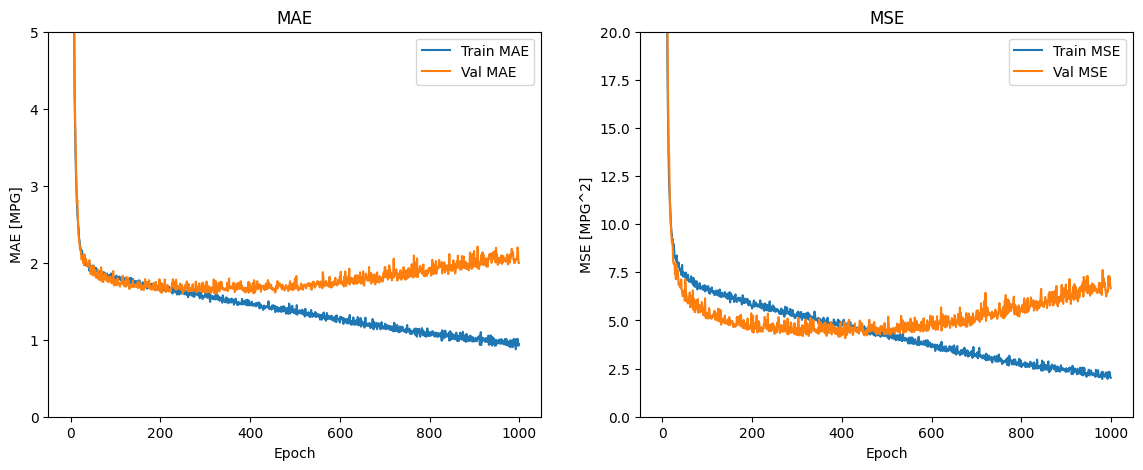

In [16]:
def plot_history(history):
    hist = pd.DataFrame(history.history)
    hist["epoch"] = history.epoch

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(hist["epoch"], hist["mae"], label="Train MAE")
    axes[0].plot(hist["epoch"], hist["val_mae"], label="Val MAE")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("MAE [MPG]")
    axes[0].set_ylim([0, 5]); axes[0].legend(); axes[0].set_title("MAE")

    axes[1].plot(hist["epoch"], hist["mse"], label="Train MSE")
    axes[1].plot(hist["epoch"], hist["val_mse"], label="Val MSE")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("MSE [MPG^2]")
    axes[1].set_ylim([0, 20]); axes[1].legend(); axes[1].set_title("MSE")

    plt.show()

plot_history(history)

¿Alguna conclusión respecto a este gráfico?

Que me puedo parar antes de las 1000 epocas. A partir de la 50, ya no mejora.

Earlystopping me ha ayudado a detener el entrenamiento para no caer en overfitting, también para ahorrar recursos innecesarios.

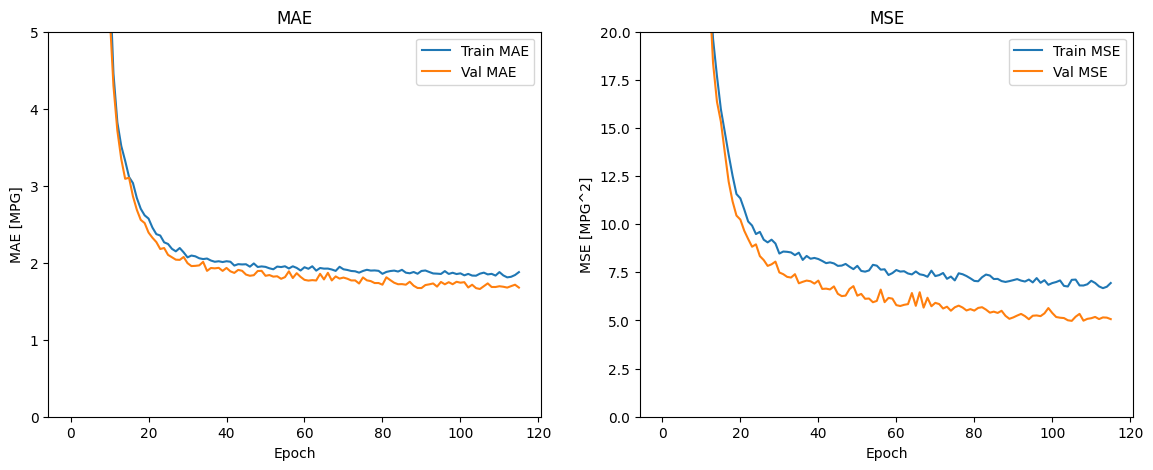

Entrenamiento detenido en la epoch 116


In [17]:
model = build_model()

early_stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=10)

history = model.fit(
    normed_train_data, train_labels,
    epochs=1000,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=0
)

plot_history(history)
print(f"Entrenamiento detenido en la epoch {len(history.epoch)}")

Interpreta el gráfico

igual que antes a partir de la epoch 50 no baja.

Veamos qué tan bien generaliza el modelo al usar el conjunto de **test**. Esto nos dice qué tan bien podemos esperar que el modelo prediga cuándo lo usamos en el mundo real. Utiliza el método `evaluate` con los datos de test normalizados y sus labels.

Con el método evaluate devolverá tres valores: loss, mae y mse.

In [18]:
loss, mae, mse = model.evaluate(normed_test_data, test_labels, verbose=0)
print(f"Test loss (MSE): {loss:.3f}")
print(f"Test MAE       : {mae:.3f} MPG")
print(f"Test MSE       : {mse:.3f}")

Test loss (MSE): 6.075
Test MAE       : 1.839 MPG
Test MSE       : 6.075


Ahora prueba el modelo. Coge 10 ejemplos de test y llama a` model.predict`.

In [19]:
sample = normed_test_data.iloc[:10]
preds  = model.predict(sample).flatten()
real   = test_labels.iloc[:10].values

pd.DataFrame({"Real": real, "Predicción": preds.round(2),
              "Error": (real - preds).round(2)})

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


,Real,Predicción,Error
0,15.0,14.880000,0.12
1,14.0,15.200000,-1.20
2,25.0,20.639999,4.36
3,24.0,22.480000,1.52
4,17.0,17.690001,-0.69
5,13.0,12.880000,0.12
6,23.0,26.500000,-3.50
7,28.0,24.230000,3.77
8,30.0,25.889999,4.11
9,31.0,28.950001,2.05


### Haz Predicciones

Dibuja en un scatter plot las predicciones de test vs sus true labels.

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


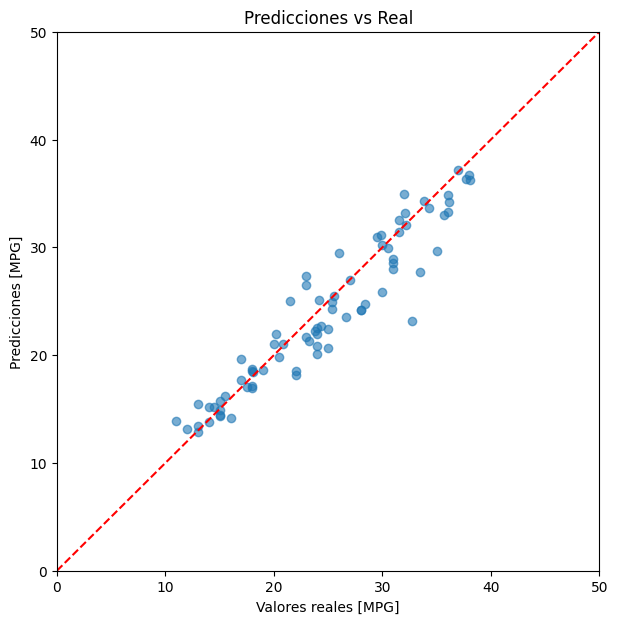

In [20]:
test_predictions = model.predict(normed_test_data).flatten()

plt.figure(figsize=(7, 7))
plt.scatter(test_labels, test_predictions, alpha=0.6)
plt.xlabel("Valores reales [MPG]")
plt.ylabel("Predicciones [MPG]")
plt.title("Predicciones vs Real")

# Línea ideal y = x
lims = [0, 50]
plt.xlim(lims); plt.ylim(lims)
plt.plot(lims, lims, "r--")
plt.show()

Parece que nuestro modelo predice razonablemente bien. Echemos un vistazo a la distribución de errores.

Representa los residuos en un histograma

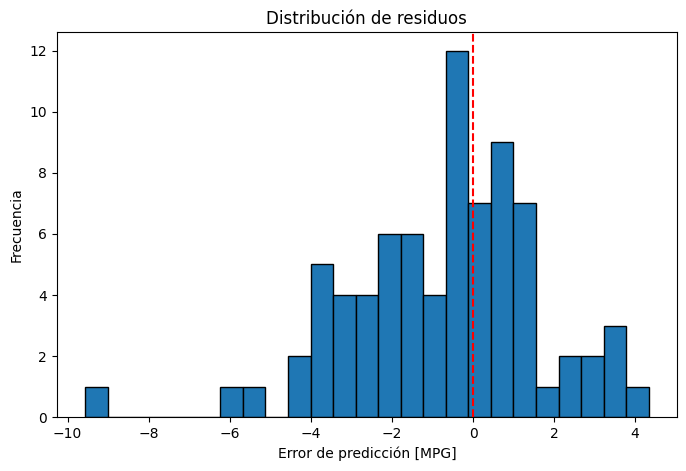

Media del error: -0.746
Std  del error : 2.349


In [21]:
errors = test_predictions - test_labels.values

plt.figure(figsize=(8, 5))
plt.hist(errors, bins=25, edgecolor="black")
plt.xlabel("Error de predicción [MPG]")
plt.ylabel("Frecuencia")
plt.title("Distribución de residuos")
plt.axvline(0, color="red", linestyle="--")
plt.show()

print(f"Media del error: {errors.mean():.3f}")
print(f"Std  del error : {errors.std():.3f}")

No es del todo gaussiano, pero podríamos esperar eso porque el número de muestras es muy pequeño.

Guarda tu modelo en un archivo.

In [22]:
model.save("auto_mpg_model.keras")
print("Modelo guardado en 'auto_mpg_model.keras'")

Modelo guardado en 'auto_mpg_model.keras'


## Conclusion

- Entrenar demasiadas epochs da overfitting
- El earlystopping para automáticamente cuando deja de mejorar, así se reduce sesgo y varianza.
- El MAE en test (~2 MPG) y los residuos centrados en 0 indican que el modelo generaliza razonablemente bien dado el tamaño del dataset.